#  Personal Finance — Deep Learning Classification

**Repo:** [AndikaHaikalS/CerminSaku](https://github.com/AndikaHaikalS/CerminSaku/tree/main/DS)

**Problem Statement:** Klasifikasi **Category** transaksi (10 kelas) berdasarkan Amount, fitur Date, dan Type — menggunakan TensorFlow Functional API.

---
### ✅ MVP Checklist
| # | Item | Status |
|---|------|--------|
| 1 | Model Deep Learning — TensorFlow Functional API | ✅ |
| 2 | Custom Layer + Custom Loss Function + Custom Callback | ✅ |
| 3 | Simpan & ekspor model (.keras / SavedModel) | ✅ |
| 4 | Kode inference model | ✅ |

---
**Dataset columns:**
- `Date` — tanggal transaksi (2020–2024)
- `Transaction Description` — deskripsi teks transaksi
- `Category` — **target** (10 kelas: Salary, Rent, Food & Drink, dll.)
- `Amount (Rupiah)` — nominal transaksi dalam Rupiah
- `Type` — Income / Expense

---
##  Cell 1 — Install & Import

In [ ]:
!pip install tensorflow scikit-learn pandas matplotlib seaborn -q

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import warnings, os
warnings.filterwarnings('ignore')

import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers, Model
from tensorflow.keras.callbacks import Callback
import tensorflow.keras.backend as K

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, LabelEncoder, OrdinalEncoder
from sklearn.metrics import classification_report, confusion_matrix


SEED = 42
np.random.seed(SEED)
tf.random.set_seed(SEED)

print(f'✅ TensorFlow versi: {tf.__version__}')
print(f'✅ GPU tersedia: {len(tf.config.list_physical_devices("GPU")) > 0}')

✅ TensorFlow versi: 2.20.0
✅ GPU tersedia: True


---
##  Cell 2 — Load Dataset dari GitHub

In [ ]:
RAW_URL     = 'https://raw.githubusercontent.com/AndikaHaikalS/CerminSaku/main/DS/Personal_Finance_Dataset_Raw.csv'
CLEANED_URL = 'https://raw.githubusercontent.com/AndikaHaikalS/CerminSaku/main/DS/Personal_Finance_Dataset_Cleaned.csv'

df = pd.read_csv(CLEANED_URL)

print(f'Shape  : {df.shape}')
print(f'Kolom  : {df.columns.tolist()}')
print(f'Missing:\n{df.isnull().sum()}')
df.head()

Shape  : (11500, 5)
Kolom  : ['Date', 'Transaction Description', 'Category', 'Amount (Rupiah)', 'Type']
Missing:
Date                       0
Transaction Description    0
Category                   0
Amount (Rupiah)            0
Type                       0
dtype: int64


,Date,Transaction Description,Category,Amount (Rupiah),Type
0,2020-01-01,Water water mall mall phone investment.,Health & Fitness,6203900,Expense
1,2020-01-01,Loan insurance.,Rent,13845100,Expense
2,2020-01-01,Health entertainment grocery fuel service pack...,Utilities,15465800,Expense
3,2020-01-01,Fee charge.,Entertainment,5675500,Expense
4,2020-01-02,Score each.,Food & Drink,14856900,Expense


---
##  Cell 3 — Exploratory Data Analysis (EDA)

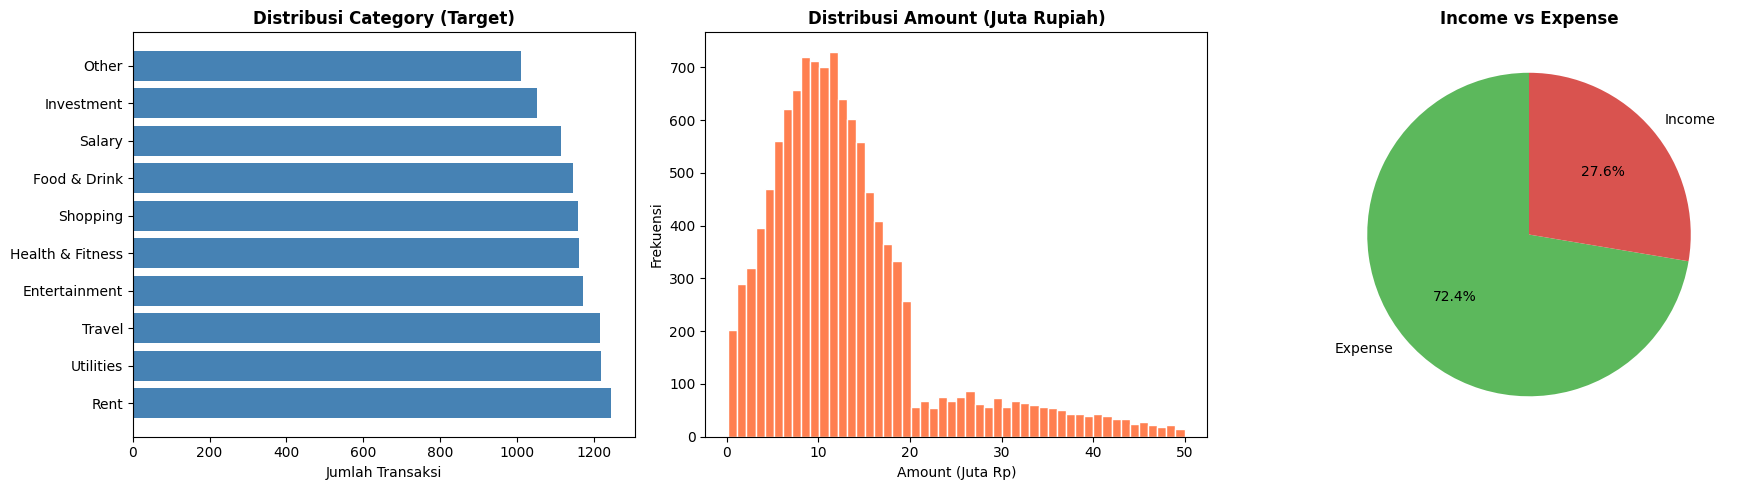


 Statistik Amount (Rupiah):
count        Rp 11,500
mean     Rp 13,064,421
std       Rp 9,062,502
min         Rp 143,700
25%       Rp 7,143,950
50%      Rp 11,248,100
75%      Rp 16,037,675
max      Rp 49,960,000
Name: Amount (Rupiah), dtype: object


In [ ]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))


category_counts = df['Category'].value_counts()
axes[0].barh(category_counts.index, category_counts.values, color='steelblue')
axes[0].set_title('Distribusi Category (Target)', fontweight='bold')
axes[0].set_xlabel('Jumlah Transaksi')


axes[1].hist(df['Amount (Rupiah)'] / 1e6, bins=50, color='coral', edgecolor='white')
axes[1].set_title('Distribusi Amount (Juta Rupiah)', fontweight='bold')
axes[1].set_xlabel('Amount (Juta Rp)')
axes[1].set_ylabel('Frekuensi')


type_counts = df['Type'].value_counts()
axes[2].pie(type_counts.values, labels=type_counts.index,
            autopct='%1.1f%%', colors=['#5cb85c', '#d9534f'], startangle=90)
axes[2].set_title('Income vs Expense', fontweight='bold')

plt.tight_layout()
plt.show()

print('\n Statistik Amount (Rupiah):')
print(df['Amount (Rupiah)'].describe().apply(lambda x: f'Rp {x:,.0f}'))

---
##  Cell 4 — Feature Engineering & Preprocessing

In [ ]:
df_proc = df.copy()


df_proc['Date'] = pd.to_datetime(df_proc['Date'])
df_proc['day_of_week']  = df_proc['Date'].dt.dayofweek
df_proc['day_of_month'] = df_proc['Date'].dt.day
df_proc['month']        = df_proc['Date'].dt.month
df_proc['quarter']      = df_proc['Date'].dt.quarter
df_proc['year']         = df_proc['Date'].dt.year
df_proc['is_weekend']   = (df_proc['day_of_week'] >= 5).astype(int)
df_proc['is_month_end'] = df_proc['Date'].dt.is_month_end.astype(int)


df_proc['type_encoded'] = (df_proc['Type'] == 'Income').astype(int)


df_proc['amount_log'] = np.log1p(df_proc['Amount (Rupiah)'])


le = LabelEncoder()
df_proc['target'] = le.fit_transform(df_proc['Category'])
NUM_CLASSES = len(le.classes_)

print(f'Jumlah kelas     : {NUM_CLASSES}')
print(f'Kelas (urutan)   : {list(le.classes_)}')
print(f'Fitur date baru  : day_of_week, day_of_month, month, quarter, year, is_weekend, is_month_end')

# --- Pilih fitur ---
FEATURE_COLS = [
    'amount_log',
    'type_encoded',
    'day_of_week',
    'day_of_month',
    'month',
    'quarter',
    'year',
    'is_weekend',
    'is_month_end'
]

X = df_proc[FEATURE_COLS].values
y = df_proc['target'].values

print(f'\nShape X: {X.shape}, Shape y: {y.shape}')

Jumlah kelas     : 10
Kelas (urutan)   : ['Entertainment', 'Food & Drink', 'Health & Fitness', 'Investment', 'Other', 'Rent', 'Salary', 'Shopping', 'Travel', 'Utilities']
Fitur date baru  : day_of_week, day_of_month, month, quarter, year, is_weekend, is_month_end

Shape X: (11500, 9), Shape y: (11500,)


In [ ]:

X_temp, X_test, y_temp, y_test = train_test_split(
    X, y, test_size=0.15, random_state=SEED, stratify=y
)
X_train, X_val, y_train, y_val = train_test_split(
    X_temp, y_temp, test_size=0.1765, random_state=SEED, stratify=y_temp
)


scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_val   = scaler.transform(X_val)
X_test  = scaler.transform(X_test)

print(f'Train : {X_train.shape} | Val : {X_val.shape} | Test : {X_test.shape}')

Train : (8049, 9) | Val : (1726, 9) | Test : (1725, 9)


---
##  Cell 5 — Custom Components

### ✅ 5a. Custom Layer — `FeatureAttentionLayer`

In [ ]:
class FeatureAttentionLayer(layers.Layer):
    """
    Custom Layer: Channel-wise Attention.
    Memberi bobot pada setiap fitur input berdasarkan relevansinya.
    Mirip dengan Squeeze-and-Excitation block tapi untuk tabular data.
    """
    def __init__(self, reduction_ratio=4, **kwargs):
        super(FeatureAttentionLayer, self).__init__(**kwargs)
        self.reduction_ratio = reduction_ratio

    def build(self, input_shape):
        n_features = input_shape[-1]
        reduced    = max(1, n_features // self.reduction_ratio)

        self.dense_squeeze = layers.Dense(reduced, activation='relu',
                                          use_bias=False, name='attn_squeeze')
        self.dense_excite  = layers.Dense(n_features, activation='sigmoid',
                                          use_bias=False, name='attn_excite')
        super().build(input_shape)

    def call(self, inputs):

        attention = self.dense_squeeze(inputs)
        attention = self.dense_excite(attention)

        return inputs * attention

    def get_config(self):
        config = super().get_config()
        config.update({'reduction_ratio': self.reduction_ratio})
        return config


print('✅ Custom Layer: FeatureAttentionLayer siap!')

✅ Custom Layer: FeatureAttentionLayer siap!


### ✅ 5b. Custom Loss Function — `FocalLoss`

In [ ]:
class FocalLoss(keras.losses.Loss):
    """
    Custom Loss: Focal Loss untuk multi-class classification.
    Fokus pada sampel yang susah diprediksi (hard examples).
    Lebih baik dari CrossEntropy standar untuk data yang imbalanced.

    Formula: FL(p_t) = -alpha * (1 - p_t)^gamma * log(p_t)
    - gamma > 0  → down-weight easy examples
    - alpha      → balancing factor
    """
    def __init__(self, gamma=2.0, alpha=0.25, **kwargs):
        super(FocalLoss, self).__init__(**kwargs)
        self.gamma = gamma
        self.alpha = alpha

    def call(self, y_true, y_pred):

        y_true_oh = tf.one_hot(tf.cast(y_true, tf.int32), depth=tf.shape(y_pred)[-1])
        y_pred    = tf.clip_by_value(y_pred, 1e-7, 1.0)


        ce = -y_true_oh * tf.math.log(y_pred)


        p_t          = tf.reduce_sum(y_true_oh * y_pred, axis=-1, keepdims=True)
        focal_weight = tf.pow(1.0 - p_t, self.gamma)

        focal_loss = self.alpha * focal_weight * ce
        return tf.reduce_mean(tf.reduce_sum(focal_loss, axis=-1))

    def get_config(self):
        config = super().get_config()
        config.update({'gamma': self.gamma, 'alpha': self.alpha})
        return config


print('✅ Custom Loss: FocalLoss siap!')

✅ Custom Loss: FocalLoss siap!


### ✅ 5c. Custom Callback — `TrainingMonitorCallback`

In [ ]:
class TrainingMonitorCallback(Callback):
    """
    Custom Callback: Monitor training per epoch.
    - Print ringkasan metrics setiap N epoch
    - Deteksi overfitting (val_loss naik tapi train_loss turun)
    - Simpan history untuk plotting
    """
    def __init__(self, print_every=5, overfit_threshold=0.05):
        super().__init__()
        self.print_every       = print_every
        self.overfit_threshold = overfit_threshold
        self.history_log       = []

    def on_train_begin(self, logs=None):
        print(' Training dimulai...\n')

    def on_epoch_end(self, epoch, logs=None):
        logs = logs or {}
        self.history_log.append(logs.copy())

        if (epoch + 1) % self.print_every == 0:
            train_loss = logs.get('loss', 0)
            val_loss   = logs.get('val_loss', 0)
            train_acc  = logs.get('accuracy', 0)
            val_acc    = logs.get('val_accuracy', 0)

            overfit_flag = ''
            if val_loss - train_loss > self.overfit_threshold:
                overfit_flag = '    Potensi overfitting!'

            print(f'[Epoch {epoch+1:3d}] '
                  f'loss={train_loss:.4f} acc={train_acc:.4f} | '
                  f'val_loss={val_loss:.4f} val_acc={val_acc:.4f}'
                  f'{overfit_flag}')

    def on_train_end(self, logs=None):
        best_epoch = np.argmin([h.get('val_loss', 999) for h in self.history_log]) + 1
        best_val   = min([h.get('val_loss', 999) for h in self.history_log])
        print(f'\n Training selesai!')
        print(f'   Best epoch    : {best_epoch}')
        print(f'   Best val_loss : {best_val:.4f}')


print('✅ Custom Callback: TrainingMonitorCallback siap!')

✅ Custom Callback: TrainingMonitorCallback siap!


---
##  Cell 6 — Build Model (TensorFlow Functional API)

In [ ]:
def build_model(input_dim, num_classes):
    """
    Model Deep Learning dengan TensorFlow Functional API.
    Arsitektur: Input → FeatureAttention → Dense Block → Residual → Output
    """
    inputs = keras.Input(shape=(input_dim,), name='input_features')


    x = FeatureAttentionLayer(reduction_ratio=4, name='feature_attention')(inputs)


    x = layers.Dense(256, name='dense_1')(x)
    x = layers.BatchNormalization(name='bn_1')(x)
    x = layers.Activation('relu', name='relu_1')(x)
    x = layers.Dropout(0.3, name='dropout_1')(x)

    x = layers.Dense(128, name='dense_2')(x)
    x = layers.BatchNormalization(name='bn_2')(x)
    x = layers.Activation('relu', name='relu_2')(x)
    x = layers.Dropout(0.3, name='dropout_2')(x)


    shortcut = layers.Dense(64, use_bias=False, name='shortcut_proj')(x)


    x = layers.Dense(64, name='dense_3')(x)
    x = layers.BatchNormalization(name='bn_3')(x)
    x = layers.Activation('relu', name='relu_3')(x)


    x = layers.Add(name='residual_add')([x, shortcut])
    x = layers.Activation('relu', name='relu_res')(x)
    x = layers.Dropout(0.2, name='dropout_3')(x)


    outputs = layers.Dense(num_classes, activation='softmax', name='output')(x)

    model = Model(inputs=inputs, outputs=outputs, name='PersonalFinance_DL')
    return model



INPUT_DIM = X_train.shape[1]
model = build_model(INPUT_DIM, NUM_CLASSES)


model.compile(
    optimizer=keras.optimizers.Adam(learning_rate=1e-3),
    loss=FocalLoss(gamma=2.0, alpha=0.25),
    metrics=['accuracy']
)

model.summary()

Model: "PersonalFinance_DL"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_features      │ (None, 9)         │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ feature_attention   │ (None, 9)         │         36 │ input_features[0… │
│ (FeatureAttentionL… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_1 (Dense)     │ (None, 256)       │      2,560 │ feature_attentio… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ bn_1                │ (None, 256)       │      1,024 │ dense_1[0][0]     │
│ (BatchNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ relu_1 (Activation) │ (None, 256)       │          0 │ bn_1[0][0]        │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_1 (Dropout) │ (None, 256)       │          0 │ relu_1[0][0]      │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_2 (Dense)     │ (None, 128)       │     32,896 │ dropout_1[0][0]   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ bn_2                │ (None, 128)       │        512 │ dense_2[0][0]     │
│ (BatchNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ relu_2 (Activation) │ (None, 128)       │          0 │ bn_2[0][0]        │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_2 (Dropout) │ (None, 128)       │          0 │ relu_2[0][0]      │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_3 (Dense)     │ (None, 64)        │      8,256 │ dropout_2[0][0]   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ bn_3                │ (None, 64)        │        256 │ dense_3[0][0]     │
│ (BatchNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ relu_3 (Activation) │ (None, 64)        │          0 │ bn_3[0][0]        │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ shortcut_proj       │ (None, 64)        │      8,192 │ dropout_2[0][0]   │
│ (Dense)             │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ residual_add (Add)  │ (None, 64)        │          0 │ relu_3[0][0],     │
│                     │                   │            │ shortcut_proj[0]… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ relu_res            │ (None, 64)        │          0 │ residual_add[0][… │
│ (Activation)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_3 (Dropout) │ (None, 64)        │          0 │ relu_res[0][0]    │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ output (Dense)      │ (None, 10)        │        650 │ dropout_3[0][0]   │
└─────────────────────┴───────────────────┴────────────┴───────────────────┘

 Total params: 54,382 (212.43 KB)

 Trainable params: 53,486 (208.93 KB)

 Non-trainable params: 896 (3.50 KB)

---
##  Cell 7 — Training

In [ ]:

monitor_cb = TrainingMonitorCallback(print_every=10, overfit_threshold=0.05)

early_stop = keras.callbacks.EarlyStopping(
    monitor='val_loss', patience=15,
    restore_best_weights=True, verbose=1
)

reduce_lr = keras.callbacks.ReduceLROnPlateau(
    monitor='val_loss', factor=0.5, patience=7,
    min_lr=1e-6, verbose=1
)


history = model.fit(
    X_train, y_train,
    validation_data=(X_val, y_val),
    epochs=100,
    batch_size=64,
    callbacks=[monitor_cb, early_stop, reduce_lr],
    verbose=0
)

 Training dimulai...

[Epoch  10] loss=0.2823 acc=0.2736 | val_loss=0.2800 val_acc=0.2532

Epoch 19: ReduceLROnPlateau reducing learning rate to 0.0005000000237487257.
[Epoch  20] loss=0.2775 acc=0.2872 | val_loss=0.2793 val_acc=0.2654
[Epoch  30] loss=0.2765 acc=0.2844 | val_loss=0.2796 val_acc=0.2694

Epoch 30: ReduceLROnPlateau reducing learning rate to 0.0002500000118743628.

Epoch 37: ReduceLROnPlateau reducing learning rate to 0.0001250000059371814.

 Training selesai!
   Best epoch    : 23
   Best val_loss : 0.2789
Epoch 38: early stopping
Restoring model weights from the end of the best epoch: 23.


---
##  Cell 8 — Evaluasi & Visualisasi

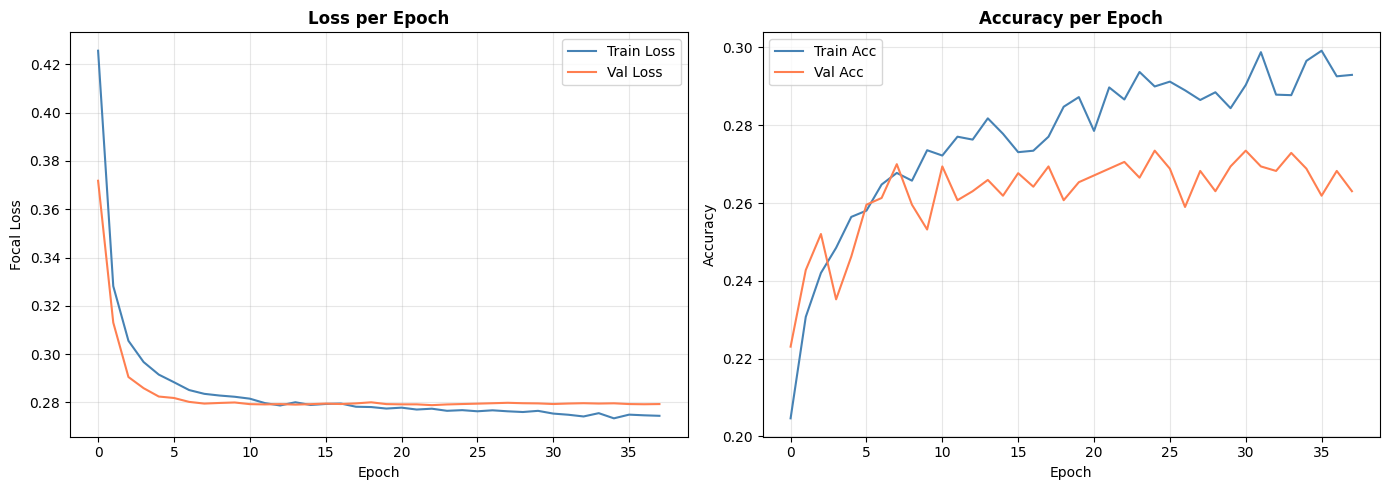

In [ ]:

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].plot(history.history['loss'],     label='Train Loss', color='steelblue')
axes[0].plot(history.history['val_loss'], label='Val Loss',   color='coral')
axes[0].set_title('Loss per Epoch', fontweight='bold')
axes[0].set_xlabel('Epoch'); axes[0].set_ylabel('Focal Loss')
axes[0].legend(); axes[0].grid(alpha=0.3)

axes[1].plot(history.history['accuracy'],     label='Train Acc', color='steelblue')
axes[1].plot(history.history['val_accuracy'], label='Val Acc',   color='coral')
axes[1].set_title('Accuracy per Epoch', fontweight='bold')
axes[1].set_xlabel('Epoch'); axes[1].set_ylabel('Accuracy')
axes[1].legend(); axes[1].grid(alpha=0.3)

plt.tight_layout()
plt.show()

In [ ]:

test_loss, test_acc = model.evaluate(X_test, y_test, verbose=0)
print(f'\n Test Loss     : {test_loss:.4f}')
print(f' Test Accuracy : {test_acc:.4f} ({test_acc*100:.2f}%)')


y_pred_proba = model.predict(X_test, verbose=0)
y_pred       = np.argmax(y_pred_proba, axis=1)

print('\n Classification Report:')
print(classification_report(y_test, y_pred, target_names=le.classes_))


 Test Loss     : 0.2776
 Test Accuracy : 0.2742 (27.42%)

 Classification Report:
                  precision    recall  f1-score   support

   Entertainment       0.13      0.26      0.18       176
    Food & Drink       0.12      0.02      0.03       172
Health & Fitness       0.00      0.00      0.00       174
      Investment       0.39      0.13      0.20       158
           Other       0.51      0.63      0.56       152
            Rent       0.16      0.27      0.20       187
          Salary       0.69      0.97      0.81       167
        Shopping       0.43      0.02      0.03       174
          Travel       0.16      0.14      0.15       182
       Utilities       0.17      0.36      0.23       183

        accuracy                           0.27      1725
       macro avg       0.28      0.28      0.24      1725
    weighted avg       0.27      0.27      0.23      1725



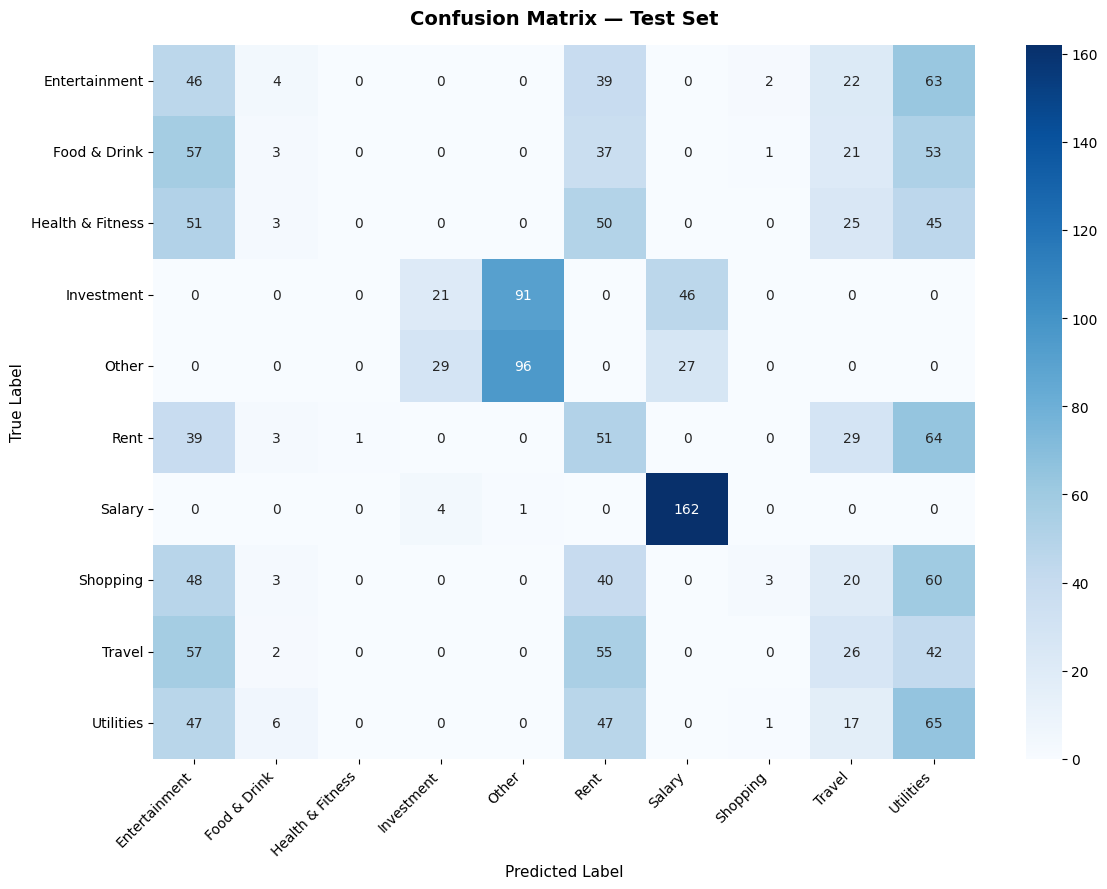

In [ ]:

cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(12, 9))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=le.classes_,
            yticklabels=le.classes_)
plt.title('Confusion Matrix — Test Set', fontsize=14, fontweight='bold', pad=15)
plt.xlabel('Predicted Label', fontsize=11)
plt.ylabel('True Label', fontsize=11)
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

---
##  Cell 9 — ✅ Simpan & Ekspor Model (Format Produksi)

In [ ]:
import pickle, json

os.makedirs('saved_model', exist_ok=True)


KERAS_PATH = 'saved_model/personal_finance_model.keras'
model.save(KERAS_PATH)
print(f'✅ Model disimpan: {KERAS_PATH}')


SAVED_MODEL_PATH = 'saved_model/personal_finance_savedmodel'
model.export(SAVED_MODEL_PATH)
print(f'✅ SavedModel disimpan: {SAVED_MODEL_PATH}/')


with open('saved_model/scaler.pkl', 'wb') as f:
    pickle.dump(scaler, f)
print(f'✅ Scaler disimpan: saved_model/scaler.pkl')

with open('saved_model/label_encoder.pkl', 'wb') as f:
    pickle.dump(le, f)
print(f'✅ LabelEncoder disimpan: saved_model/label_encoder.pkl')


metadata = {
    'feature_columns': FEATURE_COLS,
    'class_names': list(le.classes_),
    'num_classes': NUM_CLASSES,
    'input_dim': INPUT_DIM,
    'test_accuracy': float(test_acc)
}
with open('saved_model/metadata.json', 'w') as f:
    json.dump(metadata, f, indent=2)
print(f'✅ Metadata disimpan: saved_model/metadata.json')

print('\n Isi folder saved_model:')
for item in os.listdir('saved_model'):
    print(f'   {item}')

✅ Model disimpan: saved_model/personal_finance_model.keras
Saved artifact at 'saved_model/personal_finance_savedmodel'. The following endpoints are available:

* Endpoint 'serve'
  args_0 (POSITIONAL_ONLY): TensorSpec(shape=(None, 9), dtype=tf.float32, name='input_features')
Output Type:
  TensorSpec(shape=(None, 10), dtype=tf.float32, name=None)
Captures:
  133853597318992: TensorSpec(shape=(), dtype=tf.resource, name=None)
  133855813551120: TensorSpec(shape=(), dtype=tf.resource, name=None)
  133855943676496: TensorSpec(shape=(), dtype=tf.resource, name=None)
  133855943673616: TensorSpec(shape=(), dtype=tf.resource, name=None)
  133855943672272: TensorSpec(shape=(), dtype=tf.resource, name=None)
  133855813566096: TensorSpec(shape=(), dtype=tf.resource, name=None)
  133855943672656: TensorSpec(shape=(), dtype=tf.resource, name=None)
  133855943675728: TensorSpec(shape=(), dtype=tf.resource, name=None)
  133855943672080: TensorSpec(shape=(), dtype=tf.resource, name=None)
  133855943

---
##  Cell 10 — ✅ Inference Model

Kode untuk load model yang sudah disimpan dan melakukan prediksi pada data baru.

In [ ]:
import pickle, json




loaded_model = keras.models.load_model(
    'saved_model/personal_finance_model.keras',
    custom_objects={
        'FeatureAttentionLayer': FeatureAttentionLayer,
        'FocalLoss': FocalLoss
    }
)


with open('saved_model/scaler.pkl', 'rb') as f:
    loaded_scaler = pickle.load(f)

with open('saved_model/label_encoder.pkl', 'rb') as f:
    loaded_le = pickle.load(f)


with open('saved_model/metadata.json', 'r') as f:
    metadata = json.load(f)

print('✅ Model & artefak berhasil di-load!')
print(f'   Feature columns : {metadata["feature_columns"]}')
print(f'   Kelas yang bisa diprediksi: {metadata["class_names"]}')

✅ Model & artefak berhasil di-load!
   Feature columns : ['amount_log', 'type_encoded', 'day_of_week', 'day_of_month', 'month', 'quarter', 'year', 'is_weekend', 'is_month_end']
   Kelas yang bisa diprediksi: ['Entertainment', 'Food & Drink', 'Health & Fitness', 'Investment', 'Other', 'Rent', 'Salary', 'Shopping', 'Travel', 'Utilities']


In [ ]:


def predict_category(date_str, amount_rupiah, transaction_type,
                      model, scaler, le, top_k=3):
    """
    Prediksi kategori transaksi baru.

    Parameters
    ----------
    date_str         : str  — format 'YYYY-MM-DD', contoh: '2024-03-15'
    amount_rupiah    : float/int — nominal dalam Rupiah, contoh: 500000
    transaction_type : str  — 'Income' atau 'Expense'
    top_k            : int  — tampilkan top-K prediksi

    Returns
    -------
    dict berisi prediksi utama dan probabilitas semua kelas
    """

    date         = pd.to_datetime(date_str)
    type_encoded = 1 if transaction_type == 'Income' else 0
    amount_log   = np.log1p(amount_rupiah)

    features = np.array([[
        amount_log,
        type_encoded,
        date.dayofweek,
        date.day,
        date.month,
        date.quarter,
        date.year,
        int(date.dayofweek >= 5),
        int(date.is_month_end)
    ]])


    features_scaled = scaler.transform(features)


    proba      = model.predict(features_scaled, verbose=0)[0]
    pred_idx   = np.argmax(proba)
    pred_label = le.inverse_transform([pred_idx])[0]
    confidence = proba[pred_idx]

    top_k_idx    = np.argsort(proba)[::-1][:top_k]
    top_k_labels = le.inverse_transform(top_k_idx)
    top_k_proba  = proba[top_k_idx]

    return {
        'predicted_category': pred_label,
        'confidence'        : f'{confidence*100:.2f}%',
        'top_k_predictions' : list(zip(top_k_labels, [f'{p*100:.2f}%' for p in top_k_proba])),
        'all_probabilities' : dict(zip(le.classes_, [f'{p*100:.2f}%' for p in proba]))
    }


print('✅ Fungsi predict_category() siap digunakan!')

✅ Fungsi predict_category() siap digunakan!


In [ ]:


test_cases = [
    {'date': '2024-03-15', 'amount': 5_000_000,  'type': 'Expense', 'note': 'Beli baju di mall'},
    {'date': '2024-04-01', 'amount': 10_000_000, 'type': 'Income',  'note': 'Gajian awal bulan'},
    {'date': '2024-06-10', 'amount': 150_000,    'type': 'Expense', 'note': 'Makan siang'},
    {'date': '2024-07-25', 'amount': 3_500_000,  'type': 'Expense', 'note': 'Bayar listrik & air'},
    {'date': '2024-11-11', 'amount': 20_000_000, 'type': 'Income',  'note': 'Return investasi'},
]

print('=' * 65)
print(' HASIL INFERENCE')
print('=' * 65)

for i, tc in enumerate(test_cases, 1):
    result = predict_category(
        date_str=tc['date'],
        amount_rupiah=tc['amount'],
        transaction_type=tc['type'],
        model=loaded_model,
        scaler=loaded_scaler,
        le=loaded_le,
        top_k=3
    )

    print(f'\n[Transaksi {i}] {tc["note"]}')
    print(f'  Input      : {tc["date"]} | Rp {tc["amount"]:,} | {tc["type"]}')
    print(f'  Prediksi   :  {result["predicted_category"]} (confidence: {result["confidence"]})')
    print(f'  Top-3      :', ' | '.join([f'{lbl} {prb}' for lbl, prb in result['top_k_predictions']]))

print('\n' + '=' * 65)

 HASIL INFERENCE

[Transaksi 1] Beli baju di mall
  Input      : 2024-03-15 | Rp 5,000,000 | Expense
  Prediksi   :  Rent (confidence: 15.87%)
  Top-3      : Rent 15.87% | Utilities 15.71% | Health & Fitness 15.04%

[Transaksi 2] Gajian awal bulan
  Input      : 2024-04-01 | Rp 10,000,000 | Income
  Prediksi   :  Salary (confidence: 48.68%)
  Top-3      : Salary 48.68% | Investment 26.83% | Other 24.49%

[Transaksi 3] Makan siang
  Input      : 2024-06-10 | Rp 150,000 | Expense
  Prediksi   :  Utilities (confidence: 25.11%)
  Top-3      : Utilities 25.11% | Health & Fitness 16.41% | Shopping 15.20%

[Transaksi 4] Bayar listrik & air
  Input      : 2024-07-25 | Rp 3,500,000 | Expense
  Prediksi   :  Rent (confidence: 16.55%)
  Top-3      : Rent 16.55% | Utilities 16.03% | Health & Fitness 15.19%

[Transaksi 5] Return investasi
  Input      : 2024-11-11 | Rp 20,000,000 | Income
  Prediksi   :  Investment (confidence: 39.80%)
  Top-3      : Investment 39.80% | Other 38.64% | Salary 21.55%

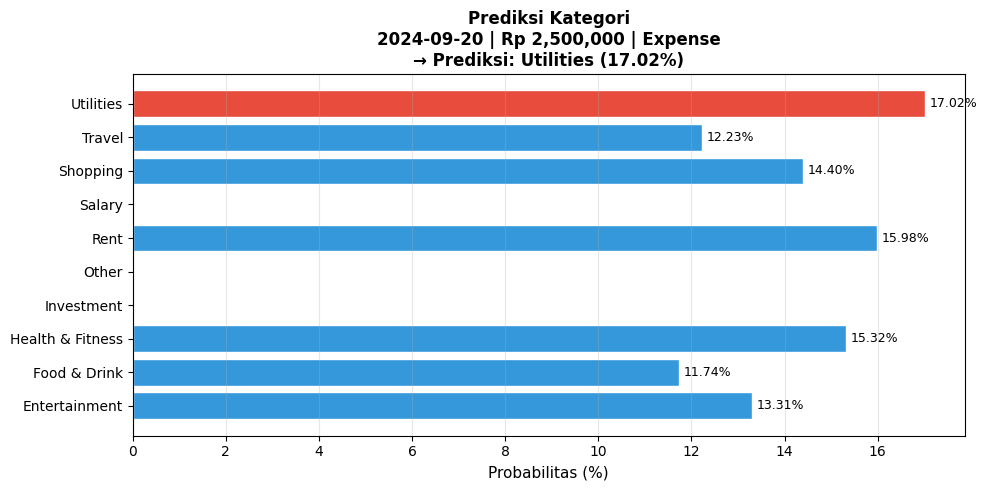

In [ ]:


sample_date   = '2024-09-20'
sample_amount = 2_500_000
sample_type   = 'Expense'

result = predict_category(
    date_str=sample_date,
    amount_rupiah=sample_amount,
    transaction_type=sample_type,
    model=loaded_model,
    scaler=loaded_scaler,
    le=loaded_le
)


categories = list(result['all_probabilities'].keys())
probs      = [float(p.replace('%','')) for p in result['all_probabilities'].values()]

colors = ['#e74c3c' if c == result['predicted_category'] else '#3498db' for c in categories]

plt.figure(figsize=(10, 5))
bars = plt.barh(categories, probs, color=colors, edgecolor='white')
plt.xlabel('Probabilitas (%)', fontsize=11)
plt.title(
    f'Prediksi Kategori\n{sample_date} | Rp {sample_amount:,} | {sample_type}\n'
    f'→ Prediksi: {result["predicted_category"]} ({result["confidence"]})',
    fontsize=12, fontweight='bold'
)
for bar, prob in zip(bars, probs):
    if prob > 0.5:
        plt.text(prob + 0.1, bar.get_y() + bar.get_height()/2,
                 f'{prob:.2f}%', va='center', fontsize=9)
plt.grid(axis='x', alpha=0.3)
plt.tight_layout()
plt.show()